# Image Classification with a Convolutional Neural Network: Baseline versus Regularised Model

**Deep learning task type:** image classification using a **Convolutional Neural Network (CNN)**, implemented in PyTorch.

**Dataset:** Fashion-MNIST (Xiao et al., 2017), published by Zalando Research under the MIT licence. It contains 70,000 real greyscale product photographs (28 by 28 pixels) in 10 clothing categories. It is a standard benchmark dataset, it is not synthetic, and it was not used in any earlier project in this programme. Official source: https://github.com/zalandoresearch/fashion-mnist

**Experiment:** a baseline CNN is compared with one modified CNN in which *only the regularisation strategy* changes (dropout and weight decay are added). Everything else is held fixed.

**Notebook structure:** 1 Setup and Task Definition, 2 Load and Inspect the Dataset, 3 Data Preparation, 4 Baseline Model, 5 Experimental Comparison, 6 Evaluation and Comparison, 7 Error Analysis, 8 Notebook Summary.

## 1. Setup and Task Definition

In [1]:
import gzip
import hashlib
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
DATA_DIR = "data"
EPOCHS = 6
BATCH_SIZE = 128
DEVICE = torch.device("cpu")
torch.set_num_threads(2)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
COLOURS = {"Baseline": "#4C78A8", "Regularised": "#E45756"}
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("PyTorch version:", torch.__version__)


def set_seed(seed):
    """Seed Python-level, NumPy and PyTorch random number generators for reproducible runs."""
    np.random.seed(seed)
    torch.manual_seed(seed)

PyTorch version: 2.14.1+cu130


**Task statement.** This is a multi-class image classification problem with ten classes. The input is a 28 by 28 greyscale image of a clothing item and the output is one of ten category labels. A CNN is the appropriate architecture because convolutional layers exploit the spatial structure of images, reusing the same small filters across the whole image so that edges and textures are detected wherever they occur.

## 2. Load and Inspect the Dataset

The four official dataset files are stored in the `data` folder next to this notebook. If they are missing, the cell below downloads them from the official repository and checks each file against the MD5 checksum published by the dataset authors, so the data are verified to be unaltered.

In [2]:
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
FILES = {  # file name -> MD5 checksum published in the official dataset README
    "train-images-idx3-ubyte.gz": "8d4fb7e6c68d591d4c3dfef9ec88bf0d",
    "train-labels-idx1-ubyte.gz": "25c81989df183df01b3e8a0aad5dffbe",
    "t10k-images-idx3-ubyte.gz": "bef4ecab320f06d8554ea6380940ec79",
    "t10k-labels-idx1-ubyte.gz": "bb300cfdad3c16e7a12a480ee83cd310",
}


def md5sum(path):
    """Return the MD5 checksum of a file."""
    with open(path, "rb") as handle:
        return hashlib.md5(handle.read()).hexdigest()


def ensure_dataset():
    """Download any missing dataset file and verify every file against its published checksum."""
    os.makedirs(DATA_DIR, exist_ok=True)
    for name, checksum in FILES.items():
        path = os.path.join(DATA_DIR, name)
        if not os.path.exists(path):
            print("Downloading", name)
            urllib.request.urlretrieve(BASE_URL + name, path)
        assert md5sum(path) == checksum, f"Checksum mismatch for {name}"
    print("All four dataset files are present and match the published checksums.")


def read_images(path):
    """Read an IDX image file into an array of shape (n, 28, 28)."""
    with gzip.open(path, "rb") as handle:
        return np.frombuffer(handle.read(), dtype=np.uint8, offset=16).reshape(-1, 28, 28)


def read_labels(path):
    """Read an IDX label file into an array of shape (n,)."""
    with gzip.open(path, "rb") as handle:
        return np.frombuffer(handle.read(), dtype=np.uint8, offset=8)


ensure_dataset()
X_train_full = read_images(os.path.join(DATA_DIR, "train-images-idx3-ubyte.gz"))
y_train_full = read_labels(os.path.join(DATA_DIR, "train-labels-idx1-ubyte.gz"))
X_test = read_images(os.path.join(DATA_DIR, "t10k-images-idx3-ubyte.gz"))
y_test = read_labels(os.path.join(DATA_DIR, "t10k-labels-idx1-ubyte.gz"))

All four dataset files are present and match the published checksums.


In [3]:
# Input shapes, data types and pixel range
print("Training images:", X_train_full.shape, X_train_full.dtype, "  labels:", y_train_full.shape, y_train_full.dtype)
print("Test images:    ", X_test.shape, X_test.dtype, "  labels:", y_test.shape, y_test.dtype)
print("Pixel value range:", X_train_full.min(), "to", X_train_full.max())
counts = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": np.bincount(y_train_full),
    "test_count": np.bincount(y_test),
})
counts

Training images: (60000, 28, 28) uint8   labels: (60000,) uint8
Test images:     (10000, 28, 28) uint8   labels: (10000,) uint8
Pixel value range: 0 to 255


,class,train_count,test_count
0,T-shirt/top,6000,1000
1,Trouser,6000,1000
2,Pullover,6000,1000
3,Dress,6000,1000
4,Coat,6000,1000
5,Sandal,6000,1000
6,Shirt,6000,1000
7,Sneaker,6000,1000
8,Bag,6000,1000
9,Ankle boot,6000,1000


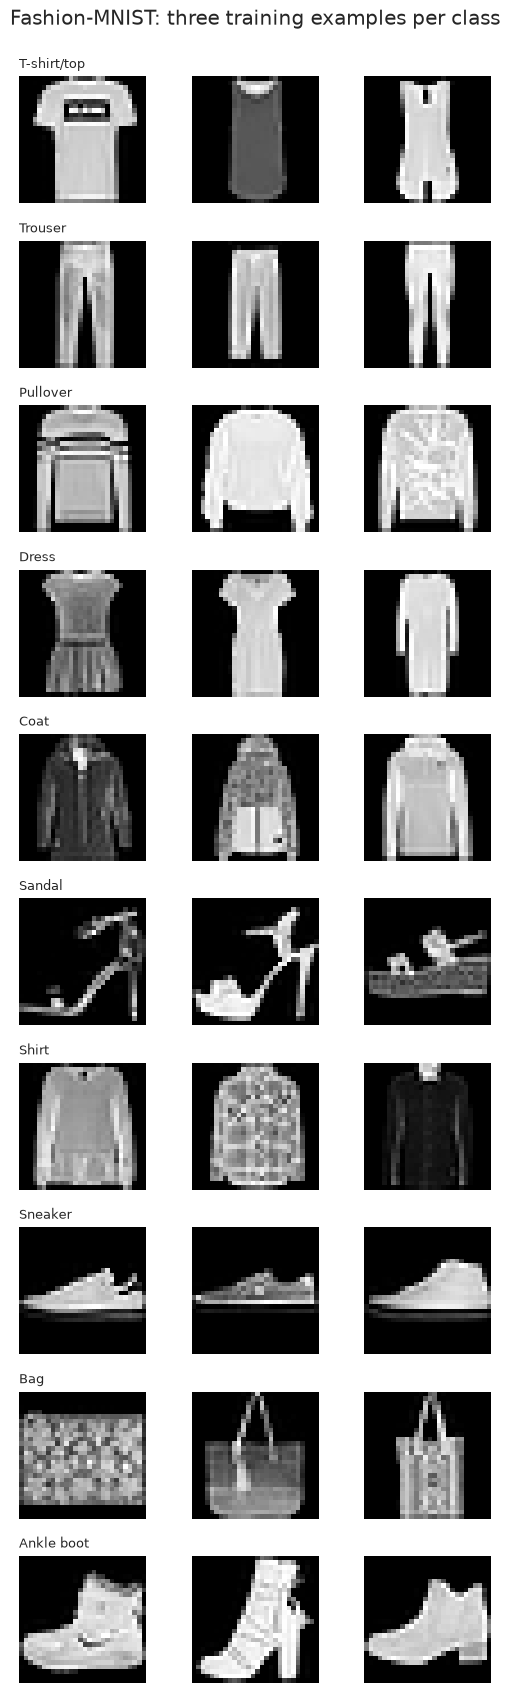

In [4]:
# Representative samples: the first three images of each class
fig, axes = plt.subplots(10, 3, figsize=(5.5, 17))
for class_id in range(10):
    idx = np.where(y_train_full == class_id)[0][:3]
    for col, i in enumerate(idx):
        ax = axes[class_id, col]
        ax.imshow(X_train_full[i], cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(CLASS_NAMES[class_id], fontsize=9, loc="left")
fig.suptitle("Fashion-MNIST: three training examples per class", y=0.995)
plt.tight_layout()
plt.savefig("figures/figure_1_sample_images.png", dpi=130)
plt.show()

**Interpretation.** The dataset contains 60,000 training and 10,000 test images, each 28 by 28 pixels with values from 0 to 255. The classes are perfectly balanced (6,000 training and 1,000 test images each), so plain accuracy is a fair headline metric, and I report macro F1 alongside it. The sample images show that some classes look alike, notably shirts, T-shirts, pullovers and coats, which is a hint about where errors will occur.

## 3. Data Preparation

**Preparation steps and reasons.**

- *Scaling.* Pixel values (0 to 255) are scaled to the range 0 to 1 and then standardised with the mean and standard deviation of the training images. Inputs with a stable scale help gradient-based training converge reliably.
- *Channel dimension.* PyTorch convolutional layers expect input of shape (batch, channels, height, width), so each image becomes a single-channel tensor of shape (1, 28, 28).
- *Validation split.* The 60,000 official training images are split into 54,000 for training and 6,000 for validation, stratified by class. The validation set is used to watch training behaviour (overfitting, stability). The official 10,000 test images are kept untouched until the final evaluation, and are never used to make any design decision.
- *No augmentation.* No data augmentation is used, so that the effect of the regularisation change in Section 5 is not mixed with another source of regularisation.

In [5]:
def prepare_tensors(images, mean=None, std=None):
    """Scale images to 0-1, standardise, and return a float tensor of shape (n, 1, 28, 28) with the mean and std used."""
    x = images.astype(np.float32) / 255.0
    if mean is None:
        mean, std = float(x.mean()), float(x.std())
    x = (x - mean) / std
    return torch.from_numpy(x).unsqueeze(1), mean, std


idx_train, idx_val = train_test_split(
    np.arange(len(y_train_full)), test_size=0.10, stratify=y_train_full, random_state=SEED)

x_train, MEAN, STD = prepare_tensors(X_train_full[idx_train])        # statistics from training images only
x_val, _, _ = prepare_tensors(X_train_full[idx_val], MEAN, STD)
x_test, _, _ = prepare_tensors(X_test, MEAN, STD)
y_train = torch.from_numpy(y_train_full[idx_train]).long()
y_val = torch.from_numpy(y_train_full[idx_val]).long()
y_test_t = torch.from_numpy(y_test).long()

print(f"Training: {len(y_train):,}   Validation: {len(y_val):,}   Test: {len(y_test_t):,}")
print(f"Training mean = {MEAN:.4f}, std = {STD:.4f}")
print("Tensor shape:", tuple(x_train.shape))
print("Validation class counts:", np.bincount(y_val.numpy()).tolist())


def make_loader(x, y, shuffle, seed=SEED):
    """Create a DataLoader. A dedicated generator keeps the batch order identical across runs that share a seed."""
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)

Training: 54,000   Validation: 6,000   Test: 10,000
Training mean = 0.2862, std = 0.3532
Tensor shape: (54000, 1, 28, 28)
Validation class counts: [600, 600, 600, 600, 600, 600, 600, 600, 600, 600]


/tmp/ipykernel_302/2283869442.py:18: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_test_t = torch.from_numpy(y_test).long()


## 4. Baseline Model

**Architecture.** The baseline is a compact CNN with two convolutional blocks followed by a small classifier:

1. `Conv2d(1 to 32 channels, 3 by 3 kernel, padding 1)`, ReLU, `MaxPool2d(2)` reduces the image from 28 by 28 to 14 by 14.
2. `Conv2d(32 to 64 channels, 3 by 3 kernel, padding 1)`, ReLU, `MaxPool2d(2)` reduces it to 7 by 7.
3. Flatten (64 x 7 x 7 = 3,136 values), `Linear(3136 to 128)`, ReLU.
4. `Linear(128 to 10)` outputs one raw score (logit) for each class.

**Design choices.** Two convolutional blocks are enough for 28 by 28 images and keep the model small enough to train on a CPU. ReLU activations avoid vanishing gradients and are cheap to compute. Max pooling halves the resolution and gives a small amount of translation tolerance. The output layer has no softmax because `CrossEntropyLoss` applies it internally, which is numerically more stable.

**Training setup.** Loss: cross-entropy. Optimiser: Adam with a learning rate of 0.001. Batch size 128, trained for a fixed number of epochs with no early stopping, so that baseline and modified models receive exactly the same training budget. The class below takes a dropout probability so that the *same architecture code* builds both models: with `dropout=0.0` the dropout layers do nothing and the network is the baseline.

In [6]:
class FashionCNN(nn.Module):
    """Two-block CNN for 28x28 greyscale images. dropout=0.0 gives the baseline model."""

    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(dropout),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 10),
        )

    def forward(self, x):
        """Return class logits of shape (batch, 10)."""
        return self.classifier(self.features(x))


baseline_example = FashionCNN(dropout=0.0)
print(baseline_example)
n_params = sum(p.numel() for p in baseline_example.parameters())
print(f"\nTrainable parameters: {n_params:,}")

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.0, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.0, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 421,642


In [7]:
def evaluate_loss_acc(model, x, y):
    """Return (mean cross-entropy loss, accuracy) of a model on a dataset, with dropout switched off."""
    model.eval()
    loss_fn = nn.CrossEntropyLoss(reduction="sum")
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for start in range(0, len(y), 1000):
            xb, yb = x[start:start + 1000], y[start:start + 1000]
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item()
            correct += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(y), correct / len(y)


def train_model(dropout, weight_decay, seed=SEED, epochs=EPOCHS, verbose=True):
    """Train a FashionCNN and return (model, history). History holds per-epoch losses, accuracies and times."""
    set_seed(seed)
    model = FashionCNN(dropout=dropout).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    loader = make_loader(x_train, y_train, shuffle=True, seed=seed)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "seconds": []}
    for epoch in range(1, epochs + 1):
        start = time.time()
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()
        # Training metrics are measured with dropout off so they are comparable with validation metrics
        train_loss, train_acc = evaluate_loss_acc(model, x_train, y_train)
        val_loss, val_acc = evaluate_loss_acc(model, x_val, y_val)
        for key, value in zip(history, [train_loss, val_loss, train_acc, val_acc, time.time() - start]):
            history[key].append(value)
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs}  train loss {train_loss:.4f}  val loss {val_loss:.4f}  "
                  f"train acc {train_acc:.4f}  val acc {val_acc:.4f}  ({history['seconds'][-1]:.1f}s)")
    return model, history

### Baseline training

In [8]:
baseline_model, baseline_hist = train_model(dropout=0.0, weight_decay=0.0)

Epoch  1/6  train loss 0.3245  val loss 0.3157  train acc 0.8846  val acc 0.8853  (28.1s)


Epoch  2/6  train loss 0.2620  val loss 0.2653  train acc 0.9068  val acc 0.9060  (28.0s)


Epoch  3/6  train loss 0.2114  val loss 0.2245  train acc 0.9235  val acc 0.9197  (29.4s)


Epoch  4/6  train loss 0.1933  val loss 0.2238  train acc 0.9299  val acc 0.9195  (27.9s)


Epoch  5/6  train loss 0.1607  val loss 0.2093  train acc 0.9420  val acc 0.9252  (26.9s)


Epoch  6/6  train loss 0.1493  val loss 0.2064  train acc 0.9454  val acc 0.9240  (26.8s)


**Interpretation.** The baseline learns quickly: validation accuracy reaches 0.9240 after six epochs. Training accuracy (0.9454) pulls ahead of validation accuracy (0.9240), a generalisation gap of 0.0214 that is still small but is widening, which is the early sign of overfitting that regularisation is meant to address.

## 5. Experimental Comparison

**What changes.** Exactly one major aspect of the baseline changes: the *regularisation strategy*. The experimental model adds **dropout** (probability 0.3 after each pooling stage and after the hidden dense layer; Srivastava et al., 2014) and **L2 weight decay** of 0.0001 in the optimiser. Both are standard regularisation tools that act on the same weakness, a model that fits the training images more closely than unseen images, and they are applied together as a single regularisation configuration.

**Why this change.** A network with about 420,000 parameters trained for many epochs on 54,000 images can start to memorise the training data. Watching the validation loss in the baseline curves shows whether that happens. Regularisation is the standard remedy, and the comparison asks whether it improves generalisation and what it costs.

**What stays identical.** The architecture and number of parameters, the number of epochs, the learning rate, the optimiser type (Adam), the batch size, the data split and preprocessing, the random seed for weight initialisation, and the order in which batches are presented. Only dropout (0.0 versus 0.3) and weight decay (0 versus 0.0001) differ.

In [9]:
CONFIGS = {
    "Baseline": {"dropout": 0.0, "weight_decay": 0.0},
    "Regularised": {"dropout": 0.3, "weight_decay": 1e-4},
}
pd.DataFrame(CONFIGS).T.assign(architecture="FashionCNN", optimiser="Adam", learning_rate=1e-3,
                               batch_size=BATCH_SIZE, epochs=EPOCHS, seed=SEED)

,dropout,weight_decay,architecture,optimiser,learning_rate,batch_size,epochs,seed
Baseline,0.0,0.0000,FashionCNN,Adam,0.001,128,6,42
Regularised,0.3,0.0001,FashionCNN,Adam,0.001,128,6,42


### Regularised model training

In [10]:
regularised_model, regularised_hist = train_model(**CONFIGS["Regularised"])

Epoch  1/6  train loss 0.3529  val loss 0.3441  train acc 0.8771  val acc 0.8770  (33.1s)


Epoch  2/6  train loss 0.2978  val loss 0.2941  train acc 0.8909  val acc 0.8898  (32.1s)


Epoch  3/6  train loss 0.2567  val loss 0.2593  train acc 0.9056  val acc 0.9033  (33.2s)


Epoch  4/6  train loss 0.2449  val loss 0.2518  train acc 0.9121  val acc 0.9082  (35.3s)


Epoch  5/6  train loss 0.2191  val loss 0.2338  train acc 0.9204  val acc 0.9132  (38.5s)


Epoch  6/6  train loss 0.2043  val loss 0.2240  train acc 0.9252  val acc 0.9167  (39.0s)


**Interpretation.** With dropout of 0.3 and weight decay of 0.0001 the regularised model learns more slowly. Its training accuracy after six epochs is 0.9252, close to its validation accuracy of 0.9167, so the gap is only 0.0086. Both curves are still rising at epoch six, so this model has not finished learning.

## 6. Evaluation and Comparison

Both models are now evaluated on the 10,000 held-out test images, which have not been used for any decision. For this balanced ten-class problem the main metrics are **accuracy**, **macro-averaged F1** (the unweighted mean of the per-class F1 scores, so every class counts equally) and **per-class precision and recall**. Training behaviour is judged from loss and accuracy curves, and from the **generalisation gap** (training accuracy minus validation accuracy).

In [11]:
def predict(model, x):
    """Return predicted class indices for a tensor of images."""
    model.eval()
    with torch.no_grad():
        return torch.cat([model(x[i:i + 1000]).argmax(1) for i in range(0, len(x), 1000)]).numpy()


models = {"Baseline": (baseline_model, baseline_hist), "Regularised": (regularised_model, regularised_hist)}
test_pred = {name: predict(m, x_test) for name, (m, _) in models.items()}

rows = []
for name, (model, hist) in models.items():
    test_loss, test_acc = evaluate_loss_acc(model, x_test, y_test_t)
    rows.append({
        "Model": name,
        "Train accuracy": hist["train_acc"][-1], "Validation accuracy": hist["val_acc"][-1],
        "Test accuracy": test_acc, "Test macro F1": f1_score(y_test, test_pred[name], average="macro"),
        "Test loss": test_loss, "Generalisation gap (train - val)": hist["train_acc"][-1] - hist["val_acc"][-1],
        "Lowest validation loss": min(hist["val_loss"]), "Epoch of lowest val loss": int(np.argmin(hist["val_loss"])) + 1,
        "Seconds per epoch": float(np.mean(hist["seconds"])),
    })
results = pd.DataFrame(rows).set_index("Model").round(4)
results.T

Model,Baseline,Regularised
Train accuracy,0.9454,0.9252
Validation accuracy,0.9240,0.9167
Test accuracy,0.9146,0.9036
Test macro F1,0.9143,0.9029
Test loss,0.2431,0.2524
Generalisation gap (train - val),0.0214,0.0086
Lowest validation loss,0.2064,0.2240
Epoch of lowest val loss,6.0000,6.0000
Seconds per epoch,27.8713,35.1842


**Interpretation.** Regularisation did what it is designed to do on the gap: the train minus validation gap fell from 0.0214 to 0.0086. It did not improve the held-out result in this run: test accuracy was 0.9146 for the baseline and 0.9036 for the regularised model, and test macro F1 was 0.9143 against 0.9029. The test set was used once, after all choices were fixed, so these figures are an unbiased estimate of performance on unseen images.

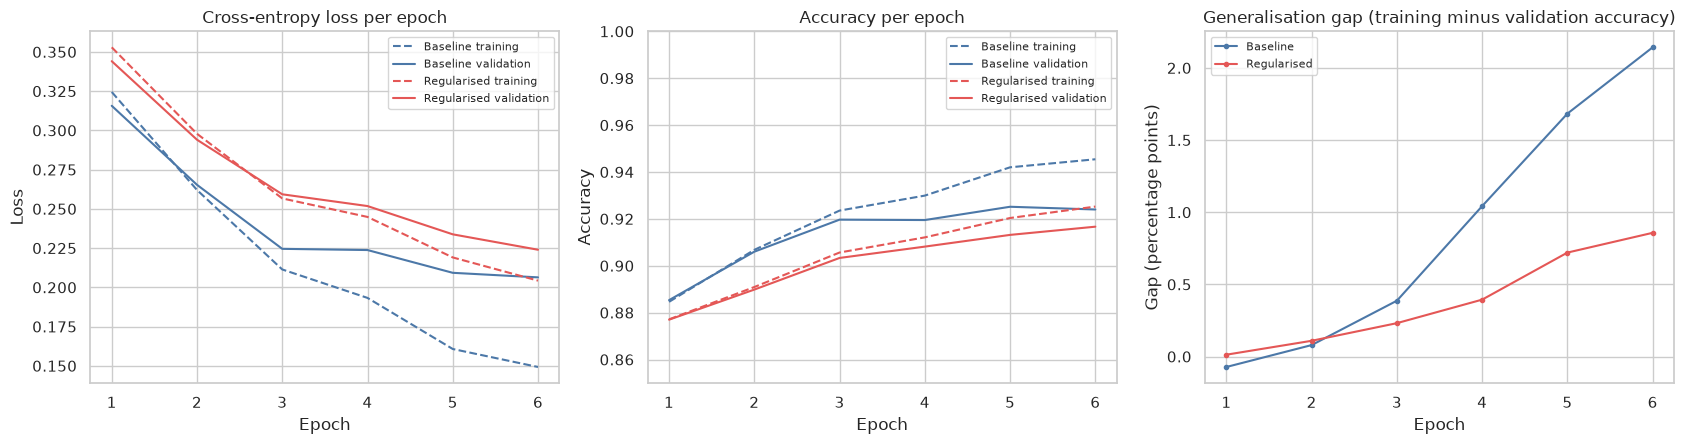

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
epochs_axis = np.arange(1, EPOCHS + 1)
for name, (_, hist) in models.items():
    axes[0].plot(epochs_axis, hist["train_loss"], color=COLOURS[name], linestyle="--", label=f"{name} training")
    axes[0].plot(epochs_axis, hist["val_loss"], color=COLOURS[name], label=f"{name} validation")
    axes[1].plot(epochs_axis, hist["train_acc"], color=COLOURS[name], linestyle="--", label=f"{name} training")
    axes[1].plot(epochs_axis, hist["val_acc"], color=COLOURS[name], label=f"{name} validation")
    gap = np.array(hist["train_acc"]) - np.array(hist["val_acc"])
    axes[2].plot(epochs_axis, gap * 100, color=COLOURS[name], marker="o", markersize=3, label=name)
axes[0].set_title("Cross-entropy loss per epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 1.0)
axes[2].set_title("Generalisation gap (training minus validation accuracy)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Gap (percentage points)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/figure_2_training_curves.png", dpi=130)
plt.show()

**Interpretation.** The baseline validation loss flattens from epoch 5 while its training loss keeps falling, so the two curves are separating. The regularised curves stay close together throughout. Neither model had reached its lowest validation loss before the final epoch, which means the training budget of six epochs, chosen for the limits of a CPU-only environment, favours the model that learns faster.

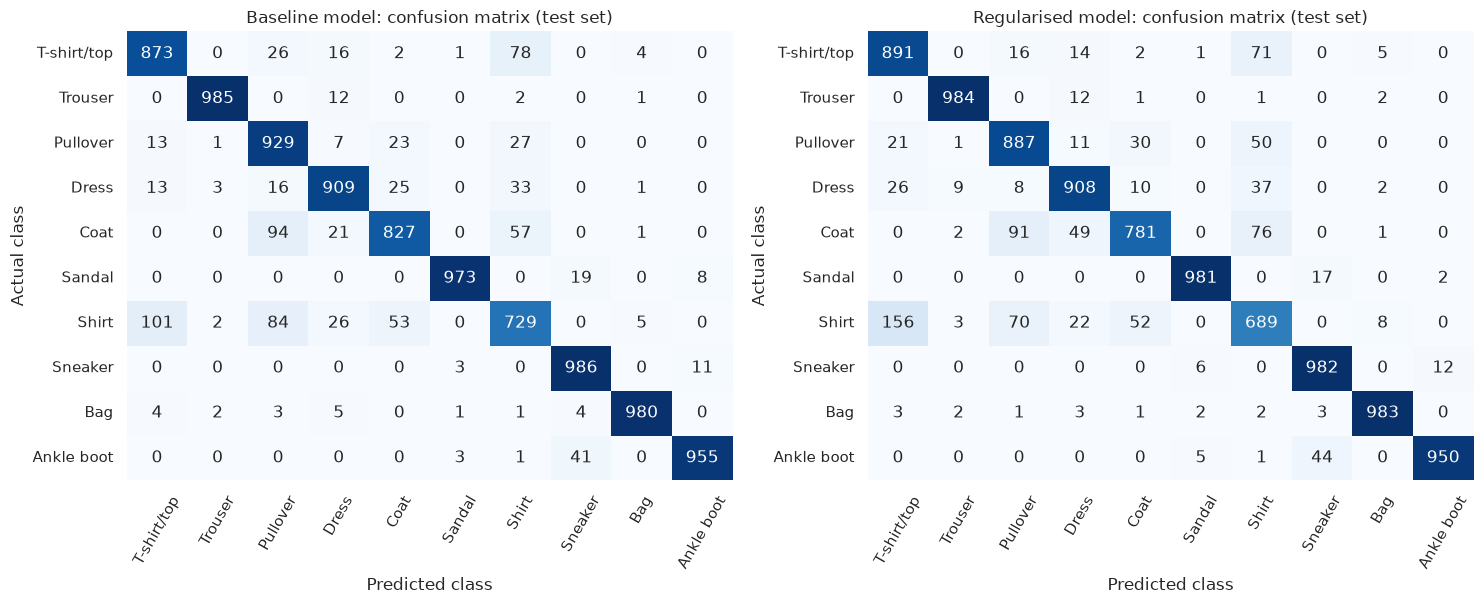

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
for ax, (name, pred) in zip(axes, test_pred.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{name} model: confusion matrix (test set)")
    ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig("figures/figure_3_confusion_matrices.png", dpi=130)
plt.show()

,Baseline F1,Regularised F1,Change
T-shirt/top,0.871,0.850,-0.021
Trouser,0.988,0.984,-0.005
Pullover,0.863,0.856,-0.008
Dress,0.911,0.899,-0.011
Coat,0.857,0.832,-0.025
Sandal,0.982,0.983,0.001
Shirt,0.756,0.715,-0.041
Sneaker,0.962,0.960,-0.002
Bag,0.984,0.983,-0.001
Ankle boot,0.968,0.967,-0.000


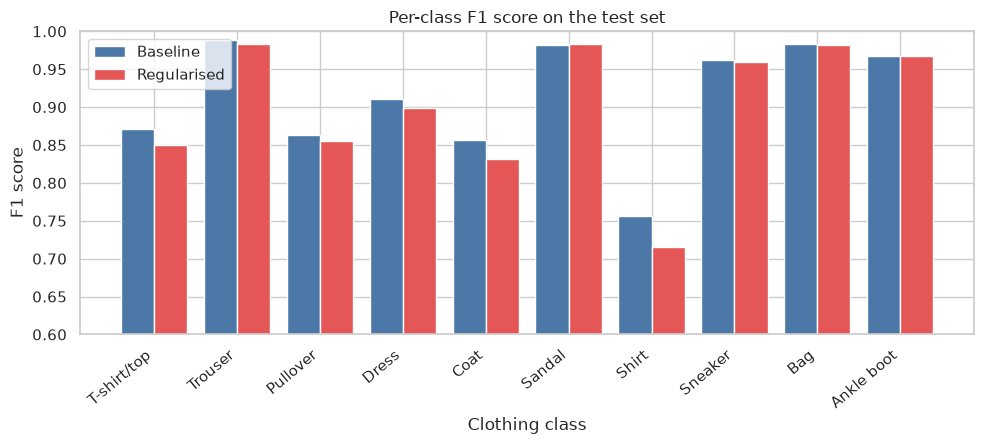

In [14]:
per_class = {}
for name, pred in test_pred.items():
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, labels=range(10), zero_division=0)
    per_class[name] = pd.DataFrame({"precision": p, "recall": r, "f1": f}, index=CLASS_NAMES)
f1_table = pd.DataFrame({"Baseline F1": per_class["Baseline"]["f1"], "Regularised F1": per_class["Regularised"]["f1"]})
f1_table["Change"] = f1_table["Regularised F1"] - f1_table["Baseline F1"]
display(f1_table.round(3))

fig, ax = plt.subplots(figsize=(10, 4.6))
width = 0.4
pos = np.arange(10)
ax.bar(pos - width / 2, f1_table["Baseline F1"], width, color=COLOURS["Baseline"], label="Baseline")
ax.bar(pos + width / 2, f1_table["Regularised F1"], width, color=COLOURS["Regularised"], label="Regularised")
ax.set_xticks(pos); ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right")
ax.set_ylim(0.6, 1.0)
ax.set_title("Per-class F1 score on the test set")
ax.set_xlabel("Clothing class"); ax.set_ylabel("F1 score")
ax.legend()
plt.tight_layout()
plt.savefig("figures/figure_4_per_class_f1.png", dpi=130)
plt.show()

**Interpretation.** The change in F1 is not spread evenly. Footwear and bag classes (Sandal, Sneaker, Bag, Ankle boot) and Trouser are essentially unchanged, all within 0.005. The cost of regularisation falls on the upper-body garments: Shirt dropped by 0.041, Coat by 0.025 and T-shirt/top by 0.021. These are exactly the classes that look most alike, so the extra noise from dropout hurt where the model most needs fine detail.

### Robustness check across random seeds

One training run per model could be a lucky or unlucky draw. To check that the comparison is not an accident of the seed, both configurations are trained again with two further seeds (the same seed is used for the baseline and the regularised model within each pair, so the comparison stays controlled).

In [15]:
seed_rows = []
for seed in [42, 1, 2]:
    for name, cfg in CONFIGS.items():
        if seed == SEED:
            model, hist = models[name]
        else:
            model, hist = train_model(**cfg, seed=seed, verbose=False)
        _, test_acc = evaluate_loss_acc(model, x_test, y_test_t)
        seed_rows.append({"Seed": seed, "Model": name, "Test accuracy": test_acc,
                          "Generalisation gap": hist["train_acc"][-1] - hist["val_acc"][-1],
                          "Final validation loss": hist["val_loss"][-1]})
seed_results = pd.DataFrame(seed_rows)
display(seed_results.round(4))
summary_over_seeds = seed_results.groupby("Model")[["Test accuracy", "Generalisation gap", "Final validation loss"]].agg(["mean", "std"]).round(4)
summary_over_seeds

,Seed,Model,Test accuracy,Generalisation gap,Final validation loss
0,42,Baseline,0.9146,0.0214,0.2064
1,42,Regularised,0.9036,0.0086,0.2240
2,1,Baseline,0.9130,0.0215,0.2100
3,1,Regularised,0.9106,0.0072,0.2112
4,2,Baseline,0.9140,0.0162,0.1985
5,2,Regularised,0.9084,0.0099,0.2293


Test accuracy         Generalisation gap          \
                     mean     std               mean     std   
Model                                                          
Baseline           0.9139  0.0008             0.0197  0.0030   
Regularised        0.9075  0.0036             0.0086  0.0013   

            Final validation loss          
                             mean     std  
Model                                      
Baseline                   0.2050  0.0059  
Regularised                0.2215  0.0093

**Interpretation.** Across three seeds the baseline averaged 0.9139 test accuracy (standard deviation 0.0008) and the regularised model 0.9075 (standard deviation 0.0036). The baseline is ahead in all three pairs, by 0.0110, 0.0024 and 0.0056, so the direction of the single-seed result holds, although the margin varies. The generalisation gap is consistently lower with regularisation (mean 0.0086 against 0.0197). With only three seeds these standard deviations are rough estimates.

## 7. Error Analysis

Overall metrics hide *which* images a model gets wrong. The cells below list the most frequent confusions and show actual misclassified test images, including cases where the two models disagree.

In [16]:
def top_confusions(y_true, y_pred, n=5):
    """Return the n most frequent (actual, predicted) mistakes as a DataFrame."""
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    pairs = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(10) for j in range(10) if cm[i, j] > 0]
    return pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:n], columns=["Actual", "Predicted", "Count"])


for name, pred in test_pred.items():
    print(f"Most frequent mistakes, {name} model:")
    display(top_confusions(y_test, pred))

Most frequent mistakes, Baseline model:


,Actual,Predicted,Count
0,Shirt,T-shirt/top,101
1,Coat,Pullover,94
2,Shirt,Pullover,84
3,T-shirt/top,Shirt,78
4,Coat,Shirt,57


Most frequent mistakes, Regularised model:


,Actual,Predicted,Count
0,Shirt,T-shirt/top,156
1,Coat,Pullover,91
2,Coat,Shirt,76
3,T-shirt/top,Shirt,71
4,Shirt,Pullover,70


Wrong in both models:                675
Wrong only in the baseline:          179
Wrong only in the regularised:       289


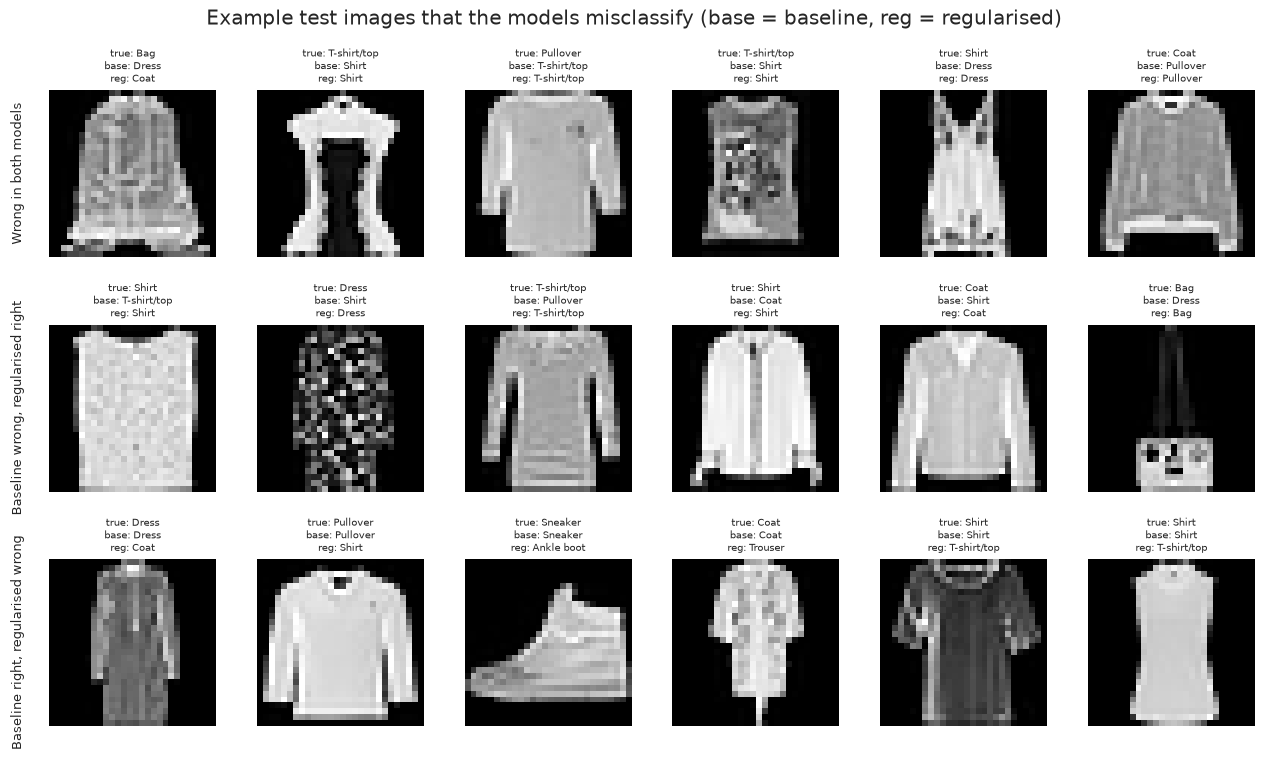

In [17]:
base_wrong = test_pred["Baseline"] != y_test
reg_wrong = test_pred["Regularised"] != y_test
print(f"Wrong in both models:              {int((base_wrong & reg_wrong).sum()):5d}")
print(f"Wrong only in the baseline:        {int((base_wrong & ~reg_wrong).sum()):5d}")
print(f"Wrong only in the regularised:     {int((~base_wrong & reg_wrong).sum()):5d}")

rng = np.random.RandomState(SEED)
groups = [("Wrong in both models", base_wrong & reg_wrong),
          ("Baseline wrong, regularised right", base_wrong & ~reg_wrong),
          ("Baseline right, regularised wrong", ~base_wrong & reg_wrong)]
fig, axes = plt.subplots(3, 6, figsize=(13, 7.6))
for row, (title, mask) in enumerate(groups):
    chosen = rng.choice(np.where(mask)[0], size=6, replace=False)
    for col, i in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(X_test[i], cmap="gray")
        ax.set_title(f"true: {CLASS_NAMES[y_test[i]]}\nbase: {CLASS_NAMES[test_pred['Baseline'][i]]}\n"
                     f"reg: {CLASS_NAMES[test_pred['Regularised'][i]]}", fontsize=7.5)
        ax.axis("off")
    axes[row, 0].text(-0.15, 0.5, title, transform=axes[row, 0].transAxes, rotation=90,
                      va="center", ha="right", fontsize=9)
fig.suptitle("Example test images that the models misclassify (base = baseline, reg = regularised)", y=0.995)
plt.tight_layout()
plt.savefig("figures/figure_5_error_examples.png", dpi=130)
plt.show()

**Interpretation.** Both models make most of their mistakes between garment types that share a silhouette. The baseline's most frequent error is a Shirt predicted as T-shirt/top (101 cases), followed by Coat predicted as Pullover (94). The regularised model makes the Shirt to T-shirt/top error far more often (156 cases). Of the test images, 675 were wrong in both models, 179 only in the baseline and 289 only in the regularised model. This concrete pattern shows that the regularised model did not fix the hard cases; it became less confident on them.

## 8. Notebook Summary

**Summary.** I compared a baseline convolutional network with a version that adds dropout (0.3) and L2 weight decay (0.0001) as a single regularisation change, using identical data, architecture, optimiser, seed and six training epochs on Fashion-MNIST. Regularisation reduced the generalisation gap from 0.0214 to 0.0086, but test accuracy fell from 0.9146 to 0.9036 and macro F1 from 0.9143 to 0.9029. A three-seed check confirmed the direction, with the baseline ahead on average (0.9139 against 0.9075). The loss was concentrated in Shirt, Coat and T-shirt/top, the visually similar classes, where Shirt was most often mistaken for T-shirt/top. I conclude that, with a short six-epoch budget, the regularisation traded accuracy for a smaller gap, and it would need longer training to show a benefit.